In [5]:
import random

def sample_dict(dictionary, sample_size=1, ordered=False):
    """
    Randomly samples a subset of aligned data from a dictionary of lists.
    
    Args:
        dictionary (dict): A dictionary where each value is a list of the same length.
        sample_size (int): Number of items to sample (default: 1).
    
    Returns:
        dict: A new dictionary with sampled data.
    """
    # Check if all lists have the same length
    lengths = [len(v) for v in dictionary.values()]
    if not all(l == lengths[0] for l in lengths):
        raise ValueError("All dictionary values must have the same length!")
    
    total_items = lengths[0]
    if sample_size > total_items:
        raise ValueError(f"Sample size ({sample_size}) exceeds total items ({total_items})!")
    
    # Generate random indices (without replacement)
    sampled_indices = random.sample(range(total_items), sample_size)
    if ordered:
        sampled_indices.sort()
    
    # Extract sampled data for each key
    sampled_data = {
        key: [value[i] for i in sampled_indices]
        for key, value in dictionary.items()
    }
    
    return sampled_data

# Example usage
data = {
    'points': [1, 2, 3, 4, 5],
    'ball_scatter_dir': ['a', 'b', 'c', 'd', 'e'],
    'other_key': [10, 20, 30, 40, 50]
}

sampled = sample_dict(data, sample_size=3, ordered=False)
print("Sampled data:", sampled)

Sampled data: {'points': [1, 5, 2], 'ball_scatter_dir': ['a', 'e', 'b'], 'other_key': [10, 50, 20]}


### remove duplicated array with complementary array

In [6]:
import numpy as np

def remove_duplicates_paired(array1: np.ndarray, array2: np.ndarray):
    """
    Keeps first occurrence of duplicates in array1 and corresponding array2 elements
    
    Args:
        array1: Array with potential duplicates (list or NumPy array)
        array2: Paired array (same length)
    
    Returns:
        Tuple of deduplicated (array1, array2) as NumPy arrays
    """
    
    # Check input lengths
    if len(array1) != len(array2):
        raise ValueError("Arrays must have the same length")
    
    # Use unique indices approach for vectorization
    _, unique_indices = np.unique(array1, return_index=True)
    unique_indices.sort()  # Maintain original order of appearance
    
    return array1[unique_indices], array2[unique_indices]

# Example Usage
array1 = ([1, 2, 2, 3, 4, 4, 4, 5])
complimentary_array = np.array(['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h'])

unique_arr1, filtered_arr2 = remove_duplicates_paired(array1, complimentary_array)
print("Unique Array 1:", unique_arr1)
print("Filtered Array 2:", filtered_arr2)

TypeError: only integer scalar arrays can be converted to a scalar index

In [ ]:
array1

array([[1, 2, 3],
       [1, 2, 4],
       [1, 2, 4],
       [1, 2, 5],
       [1, 2, 6],
       [1, 2, 6]])

In [ ]:
import numpy as np

def remove_duplicates_paired(array1, array2):
    """
    Removes duplicates from paired arrays of mixed scalar/array elements
    Keeps first occurrence of duplicates in array1 and corresponding array2 elements
    
    Args:
        array1: Array with potential duplicates (list or NumPy array)
        array2: Paired array (same length)
    
    Returns:
        Tuple of deduplicated (array1, array2) in same format as input
    """
    # Convert to numpy arrays of objects to handle mixed types
    arr1 = np.asarray(array1, dtype=object)
    arr2 = np.asarray(array2, dtype=object)
    
    if len(arr1) != len(arr2):
        raise ValueError("Arrays must be of the same length")
    
    seen = {}
    unique_mask = np.ones(len(arr1), dtype=bool)
    
    for i, item in enumerate(arr1):
        # Create a consistent hashable representation
        if isinstance(item, np.ndarray):
            # For arrays, use tuple representation (shape + flattened values)
            signature = (item.shape, item.tobytes())
        elif isinstance(item, (list, tuple)):
            # For sequences, convert to tuple
            signature = tuple(item)
        else:
            # For scalars, use as-is
            signature = item
        
        # Check if we've seen this signature before
        if signature in seen:
            unique_mask[i] = False
        else:
            seen[signature] = True  # Mark as seen
    
    return arr1[unique_mask], arr2[unique_mask]

# Example usage
array1 = [
    1, 
    np.array([1, 2, 3]),
    np.array([1, 2, 3]),  # Duplicate of previous array
    3,
    np.array([4, 5]),
    np.array([[4, 5], [6, 7]]),
    np.array([[4, 5], [6, 7]]),  # Duplicate of previous array
    np.array([1, 2, 3]),  # Another duplicate
    5
]

array2 = [
    1, 
    np.array([1, 2, 3]),
    np.array([1, 2, 3]),  # Duplicate of previous array
    3,
    np.array([4, 5]),
    np.array([[4, 5], [6, 7]]),
    np.array([[4, 5], [6, 7]]),  # Duplicate of previous array
    np.array([1, 2, 3]),  # Another duplicate
    5
]
array1 = np.asarray(array1, dtype=object)
array2 = np.asarray(array2, dtype=object)
unique_arr1, filtered_arr2 = remove_duplicates_paired(array1, array2)

print("Deduplicated array1:")
print(unique_arr1)
        
print("\nFiltered array2:")
print(filtered_arr2)

Deduplicated array1:
[1 array([1, 2, 3]) 3 array([4, 5]) array([[4, 5],
                                           [6, 7]]) 5]

Filtered array2:
[1 array([1, 2, 3]) 3 array([4, 5]) array([[4, 5],
                                           [6, 7]]) 5]


In [ ]:
def contains_vector(vector: list, list_of_vectors: list[list]) -> bool:
    """
    Check if a vector (list) exists in a list of vectors using set membership for O(1) lookup.
    
    Args:
        vector (list): The vector to check (e.g., [1, 2, 3]).
        list_of_vectors (list[list]): List of vectors to search in (e.g., [[1, 2, 3], [4, 5, 6]]).
    
    Returns:
        bool: True if the vector is found, False otherwise.
    """
    # Convert list of vectors to a set of tuples (hashable)
    vectors_set = {tuple(v) for v in list_of_vectors}
    # Convert the input vector to a tuple for comparison
    return tuple(vector) in vectors_set


# Example Usage
if __name__ == "__main__":
    # Test data
    data = {
        "fruits": ["apple", "banana", "orange", "grape"],
        "numbers": np.array([[1, 2, 3], [1, 2, 5], [1, 2, 6], [1, 2, 7], [1, 2, 8]])
    }
    # Check for a vector using the function
    number_to_check = np.array([1, 2, 4])
    result = contains_vector(number_to_check, data["numbers"])
    print(f"{number_to_check} in numbers? {'Yes' if result else 'No'}")

[1 2 4] in numbers? No


In [11]:
a = np.array([1,2,3])
b = [a]
b[0][:-2]

array([1])

Merge dictionary


In [8]:
def merge_dict(dict1, dict2):
    """Merge dict2 into dict1 in-place. Returns 1 on success, 0 on error."""
    try:
        dict1.update(dict2)
        return 1
    except (TypeError, AttributeError):
        return 0
    
a = {'x': 1, 'y': 2}
b = {'y': 3, 'z': 4}

result = merge_dict(a, b)
print(result)  # Output: 1
print(a)       # Output: {'x': 1, 'y': 3, 'z': 4}

1
{'x': 1, 'y': 3, 'z': 4}


Vector uniqueness

In [64]:
def get_uniqueness_score(input_vector, set_vectors):
    """
    Calculates the uniqueness score of an input vector relative to a set of vectors.
    
    Parameters:
    input_vector (np.ndarray): A 1D numpy array of shape (n) representing the input vector.
    set_vectors (np.ndarray): A 2D numpy array of shape (m, n) representing the set of vectors.
    
    Returns:
    float: The uniqueness score, which is a ratio adjusted by a penalty factor.
    """
    input_vector = np.asarray(input_vector)
    set_vectors = np.asarray(set_vectors)

    # Validate input dimensions
    assert input_vector.ndim == 1, "input_vector must be a 1D array"
    assert set_vectors.ndim == 2, "set_vectors must be a 2D array"
    assert input_vector.shape[0] == set_vectors.shape[1], "Feature dimension mismatch between input_vector and set_vectors"
    
    # Compute centroid of the set vectors
    centroid = np.mean(set_vectors, axis=0)
    
    # Calculate distances from each vector in the set to the centroid
    distances_to_centroid = np.linalg.norm(set_vectors - centroid, axis=1)
    avg_dist_centroid = np.mean(distances_to_centroid)
    
    # Handle case where all vectors in the set are nearly identical (zero diversity)
    epsilon = 1e-9
    if avg_dist_centroid < epsilon:
        # Compute distances from input to each vector in the set
        distances_to_input = np.linalg.norm(set_vectors - input_vector, axis=1)
        min_dist = np.min(distances_to_input)
        
        if min_dist < epsilon:
            # Input is nearly identical to the set vectors
            return 0.0
        else:
            # Input is distinct from the (nearly identical) set vectors
            return min_dist
    
    # Calculate distances from input vector to each vector in the set
    distances_to_input = np.linalg.norm(set_vectors - input_vector, axis=1)
    avg_dist_input = np.mean(distances_to_input)
    min_dist = np.min(distances_to_input)
    
    # Compute the ratio of min distance to average centroid distance (penalty factor base)
    r = min_dist / avg_dist_centroid
    penalty_factor = sigmoid(r-0.5)  # Linear penalty factor
    
    # Compute the uniqueness score
    uniqueness_score = (avg_dist_input / avg_dist_centroid) * penalty_factor

    print(f"distances_to_input: {avg_dist_input}, avg_dist_centroid: {avg_dist_centroid}")
    
    return uniqueness_score

In [69]:
# Test case 1: Identical to existing vector
x1 = np.array([1, 0])
vectors1 = np.array([[1, 0], [1, 0]])
print(f"Identical: {get_uniqueness_score(x1, vectors1):.6f}")  # 0.0

# Test case 2: Moderately close
x2 = np.array([1.05, 0])
vectors2 = np.array([[1, 0], [2, 0]])
print(f"Moderately close: {get_uniqueness_score(x2, vectors2):.6f}")  # ~0.0000

# Test case 3: Distinctive position
x3 = np.array([0, 2])
vectors3 = np.array([[0, 0], [1, 0], [0, 1]])
print(f"Distinctive: {get_uniqueness_score(x3, vectors3):.6f}")  # ~0.0163

# Test case 4: Very far
x4 = np.array([2, 2])
vectors4 = np.array([[0, 0], [1, 0], [0, 1]])
print(f"Far away: {get_uniqueness_score(x4, vectors4):.6f}")  # ~0.9894

# Test case 5: Single vector
x5 = np.array([2, 2])
vectors5 = np.array([[0, 0]])
print(f"Single vector: {get_uniqueness_score(x5, vectors5):.6f}")  # ~0.0039


Identical: 0.000000
distances_to_input: 0.5, avg_dist_centroid: 0.5
Moderately close: 0.017986
distances_to_input: 1.74535599249993, avg_dist_centroid: 0.6540388352636305
Distinctive: 2.668491
distances_to_input: 2.433521026581923, avg_dist_centroid: 0.6540388352636305
Far away: 3.720759
Single vector: 2.828427


In [76]:
a = [1,2,3,7,8,9]
b = np.array(a)
b/b

array([1., 1., 1., 1., 1., 1.])

In [73]:
spawn_unique_highest = float('-inf')
if get_uniqueness_score(x5, vectors5) > spawn_unique_highest:
    print("ok")

ok


In [80]:
a = [0, 1,3,4,5,6,7,8,9]
a[-2:]

[8, 9]

Vector sphere

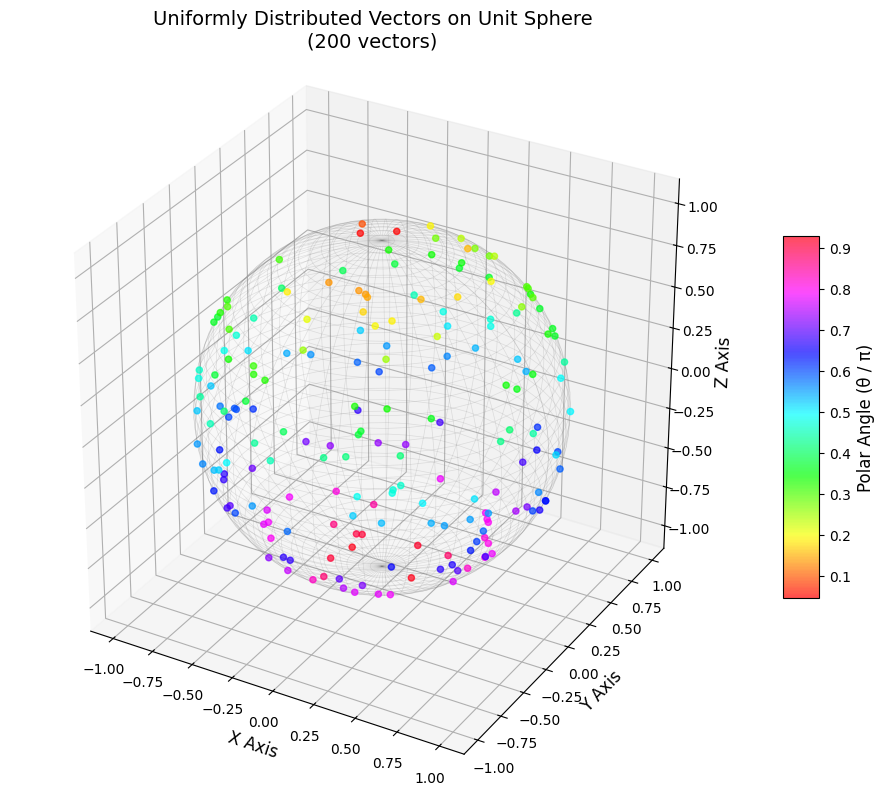

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def get_vector_sphere(num_vectors):
    """
    Generates 'num_vectors' uniformly distributed 3D unit vectors.
    """
    vectors = np.random.normal(size=(num_vectors*100, 3))
    norms = np.linalg.norm(vectors, axis=1, keepdims=True)
    unit_vectors = vectors / norms  # Normalize to unit length
    return unit_vectors[np.random.choice(unit_vectors.shape[0], size=num_vectors, replace=False), :]

def visualize_with_matplotlib(num_vectors=200):
    # Generate uniformly distributed unit vectors
    vectors = get_vector_sphere(num_vectors)

    # Extract x, y, z coordinates of vector tips
    x, y, z = vectors[:, 0], vectors[:, 1], vectors[:, 2]

    # Create a 3D plot
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # --------------------------
    # Plot wireframe sphere (reference)
    # --------------------------
    # Generate grid for sphere surface
    u = np.linspace(0, 2 * np.pi, 50)  # Azimuthal angle (0 to 2π)
    v = np.linspace(0, np.pi, 50)     # Polar angle (0 to π)
    
    # Compute sphere coordinates
    x_sphere = np.outer(np.sin(v), np.cos(u))  # x = sin(v)cos(u)
    y_sphere = np.outer(np.sin(v), np.sin(u))  # y = sin(v)sin(u)
    z_sphere = np.outer(np.cos(v), np.ones_like(u))  # z = cos(v)
    
    # Plot wireframe sphere (alpha for transparency)
    ax.plot_wireframe(x_sphere, y_sphere, z_sphere, 
                      color='gray', alpha=0.2, linewidth=0.5)

    # --------------------------
    # Plot vector tips as scatter points
    # --------------------------
    # Color points by their polar angle (theta) for visual appeal
    theta = np.arccos(z)  # Polar angle (0 at north pole, π at south pole)
    colors = theta / np.pi  # Normalize to [0, 1] for colormap
    
    # Scatter plot (adjust size and alpha for visibility)
    sc = ax.scatter(x, y, z, 
                    c=colors,       # Color by polar angle
                    cmap='hsv',     # Use HSV colormap (circular color wrap)
                    s=20,           # Point size
                    alpha=0.7)      # Slight transparency

    # --------------------------
    # Add labels, title, and colorbar
    # --------------------------
    ax.set_xlabel('X Axis', fontsize=12)
    ax.set_ylabel('Y Axis', fontsize=12)
    ax.set_zlabel('Z Axis', fontsize=12)
    ax.set_title(f'Uniformly Distributed Vectors on Unit Sphere\n({num_vectors} vectors)', 
                 fontsize=14)
    
    # Add colorbar to show polar angle (theta)
    cbar = plt.colorbar(sc, shrink=0.5, aspect=10)
    cbar.set_label('Polar Angle (θ / π)', fontsize=12)

    # --------------------------
    # Adjust axes to be equal (critical for sphere visualization!)
    # --------------------------
    ax.set_box_aspect([1, 1, 1])  # Force equal scaling on all axes

    # Show the plot
    plt.tight_layout()
    plt.show()

# Run the visualization with 200 vectors
if __name__ == "__main__":
    visualize_with_matplotlib(num_vectors=200)

### Custom python fixed size list

In [1]:
class FixedSizeArray:
    def __init__(self, max_size):
        if max_size < 0:
            raise ValueError("max_size must be >= 0")
        self.max_size = max_size
        self._data = [None] * max_size  # Fixed-size internal storage
        self._size = 0  # Current number of elements (can be < max_size)

    def append(self, item):
        if self._size >= self.max_size:
            raise IndexError(f"Cannot append: FixedSizeArray is full (max_size={self.max_size})")
        self._data[self._size] = item
        self._size += 1

    def pop(self):
        if self._size == 0:
            raise IndexError("pop from empty FixedSizeArray")
        self._size -= 1
        item = self._data[self._size]
        self._data[self._size] = None  # Optional cleanup
        return item

    def __getitem__(self, index):
        if isinstance(index, slice):
            # Handle slicing (optional but useful)
            return self._data[:self._size][index]
        if index < 0:
            index += self._size
        if index < 0 or index >= self._size:
            raise IndexError(f"Index {index} out of range for size {self._size}")
        return self._data[index]

    def __setitem__(self, index, value):
        if isinstance(index, slice):
            raise NotImplementedError("Slicing assignment not supported")
        if index < 0:
            index += self._size
        if index < 0 or index >= self._size:
            raise IndexError(f"Index {index} out of range for size {self._size}")
        self._data[index] = value

    def __len__(self):
        return self._size

    def __repr__(self):
        return f"FixedSizeArray({self._data[:self._size]}, max_size={self.max_size})"

    # Optional: support iteration
    def __iter__(self):
        return iter(self._data[:self._size])

In [6]:
# Create a fixed-size array of max 3 elements
arr = FixedSizeArray(3)

arr.append(10)
arr.append(20)
arr.append(30)
print(arr)        # FixedSizeArray([10, 20, 30], max_size=3)

# Try to append more → ERROR
try:
    arr.append(40)
except IndexError as e:
    print("Error:", e)  # Error: Cannot append: FixedSizeArray is full (max_size=3)

# Pop an item
print(arr.pop())   # 30
print(arr)         # FixedSizeArray([10, 20], max_size=3)

# Indexing
arr.append(30)
print(arr[0])      # 10
print(arr[-1])      # 30

arr[0] = 999
print(arr[0])      # 999

# Iteration
for x in arr:
    print(x)       # 999, 20, 30

# appending objects
dictionary = {
    'a': 1,
    'b': [1,2,3],
    'c': "asdf",
}

arr = FixedSizeArray(3)
arr.append(dictionary)
arr.append(dictionary)
arr.append(dictionary)
print(arr)

FixedSizeArray([10, 20, 30], max_size=3)
Error: Cannot append: FixedSizeArray is full (max_size=3)
30
FixedSizeArray([10, 20], max_size=3)
10
30
999
999
20
30
FixedSizeArray([{'a': 1, 'b': [1, 2, 3], 'c': 'asdf'}, {'a': 1, 'b': [1, 2, 3], 'c': 'asdf'}, {'a': 1, 'b': [1, 2, 3], 'c': 'asdf'}], max_size=3)


### centering point cloud

In [10]:
import open3d as o3d
import numpy as np
import os

def center_open3d_ply(input_path, output_path):
    """
    Centers a PLY point cloud at the origin (0,0,0) using Open3D and saves result
    
    Args:
        input_path: Path to input PLY file
        output_path: Path for centered output PLY file
    """
    # Read input point cloud
    pcd = o3d.io.read_point_cloud(input_path)
    
    # Validate point cloud
    if not pcd.has_points():
        raise ValueError("Input file contains no point data")
        
    # Calculate centroid using Open3D's efficient operations
    points = np.asarray(pcd.points)
    centroid = np.mean(points, axis=0)
    
    # Center points at origin
    centered_points = points - centroid
    
    # Create new point cloud preserving all attributes
    centered_pcd = o3d.geometry.PointCloud()
    centered_pcd.points = o3d.utility.Vector3dVector(centered_points)
    
    # Preserve colors if present
    if pcd.has_colors():
        centered_pcd.colors = pcd.colors
    
    # Preserve normals if present
    if pcd.has_normals():
        centered_pcd.normals = pcd.normals
    
    # Save centered point cloud
    o3d.io.write_point_cloud(output_path, centered_pcd, write_ascii=False)
    print(f"pcd points count: {len(centered_pcd.points)}")
    # Return centroid for verification
    return centroid

# Example usage
if __name__ == "__main__":
    input_file = "../ply_files/reconstructed/full_tsdf_layer0_tsdf0_cleaned.ply"
    output_file = "centered_cloud.ply"
    print(os.getcwd())
    
    centroid = center_open3d_ply(input_file, output_file)
    print(f"Point cloud centered at origin")
    print(f"Original centroid: {centroid}")
    print(f"Saved centered cloud to: {output_file}")


c:\Users\ASUS\OneDrive - HKUST Connect\1_Projects\ASTRI\Project folder\Hole detection\scripts
pcd points count: 41716
Point cloud centered at origin
Original centroid: [2.35547781 2.38152291 2.2478748 ]
Saved centered cloud to: centered_cloud.ply
